In [1]:
#Load packages
library(tidyverse)
library(viridis)

Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite



In [16]:
#Read in metadata
metadat<-read.csv('/home/jbos/Moz_reads/Acropora_moz_metadat_certainty.csv')

In [2]:
#Read in PAC output
angsdpca<-as.matrix(read.table('/scratch/jbos/Moz_aligned_mil/angsd1_output/angsd_acropora_pca.cov'))

In [3]:
#Get list of BAMfiles used in ANGSD
bamlist<-read.table('/home/jbos/Moz_reads/bamlist_amillepora.txt')

In [4]:
#Function to get sample names from bamfiles
bamnames<-function(bam){
    a<-strsplit(bam,'files/')[[1]][2]
    b<-strsplit(a,'.s')[[1]][1]
    return(b)
    }

In [5]:
#Get sample names from bamfiles
bams<-apply(bamlist,FUN=bamnames,MARGIN=1)

In [6]:
#Name rows and columns of PCANGSD matrix
colnames(angsdpca)<-bams
rownames(angsdpca)<-bams

In [7]:
# Eigen-decomposition
eigen1 <- eigen(angsdpca)

In [8]:
# Extract eigenvalues
eigenvalues <- eigen1$values

In [9]:
# Extract eigenvectors
eigenvectors <- eigen1$vectors
rownames(eigenvectors)<-bams

In [11]:
# Calculate variance explained
var_explained <- eigenvalues / sum(eigenvalues)
var_explained[1:5]

[1] 0.20715204 0.14156834 0.02323926 0.02158432 0.01939764

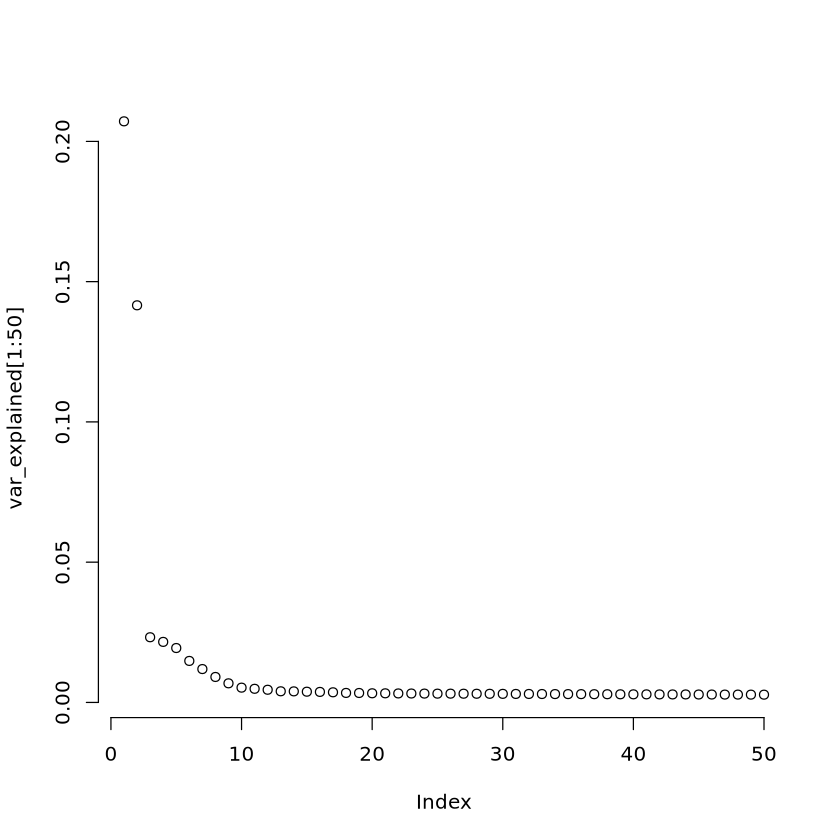

In [12]:
#Plot variance explained for each PC
plot(var_explained[1:50],axes=FALSE)
axis(1)
axis(2)

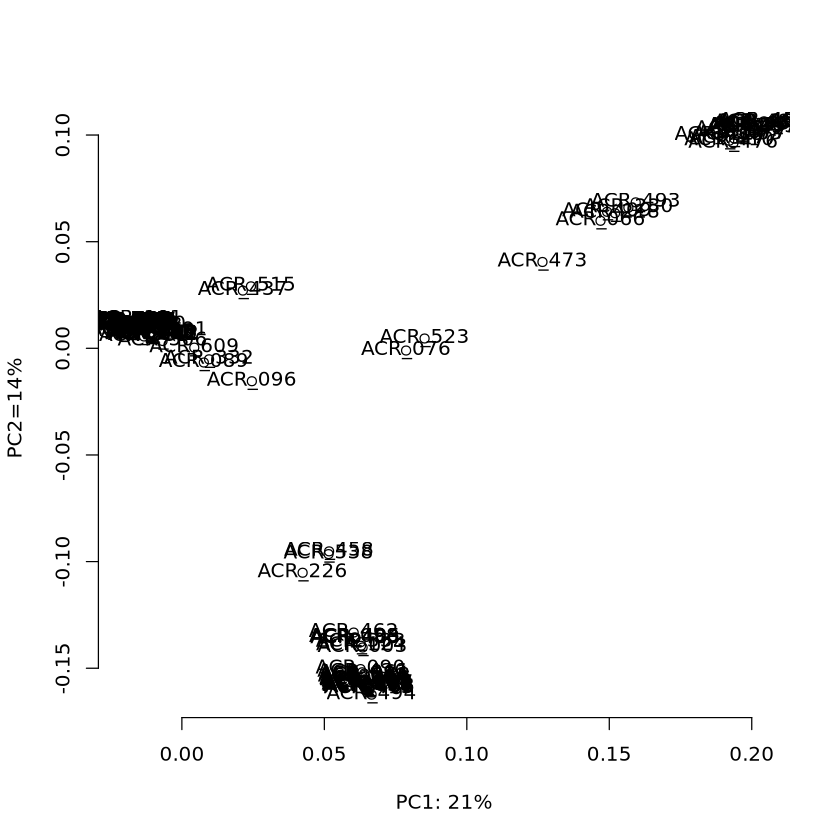

In [13]:
#Plot individual sample names onf first two PCs
plot(eigenvectors[,1],eigenvectors[,2],xlab="PC1: 21%", ylab="PC2=14%",axes=FALSE)
axis(1)
axis(2)
text(eigenvectors[,1],eigenvectors[,2],labels=rownames(eigenvectors))

In [15]:
#Little function to rename samples from metadata
leading_zeros<-function(num){
    if (nchar(as.character(num))<2){
        return(paste0('00',num))
        } else {
        if (nchar(as.character(num))<3){
            return(paste0('0',num))
            } else {
       return(as.character(num))
            }
        }
    }

In [19]:
#Fix up sample names in metadata to match BAMfile names. Rename rows
metadat$Numero_do_tubo<-sapply(metadat$Numero_do_tubo,leading_zeros)
metadat$IND<-paste("ACR_",metadat$Numero_do_tubo,sep="")
rownames(metadat)<-metadat$IND

In [18]:
#Convert PC matrix to dataframe
eg2<-as.data.frame(eigenvectors)
eg2$IND<-bams

In [20]:
#Merge PCAs and metadata
combined_pca<-inner_join(eg2,metadat)
nrow(combined_pca)

Joining with `by = join_by(IND)`


[1] 310

In [21]:
#Add some relevent variables. SppIDCertainty is field notes on morphology: individuals labeled 'B' are *probably* not target species
combined_pca$SppIDCertainty<-as.factor(combined_pca$SppIDCertainty)
combined_pca$AltSpp<-as.factor(combined_pca$Spp)
combined_pca$Loc<-as.factor(combined_pca$Loc)

In [22]:
combined_pca$combined_certainty<-'U'
combined_pca$combined_certainty[combined_pca$SppIDCertainty=='C']<-'C'
combined_pca$combined_certainty[combined_pca$Spp=='B']<-'B'

In [24]:
#Dataset of on 2024 data to be used for bleaching analysis
combined24<-combined_pca[combined_pca$Ano==2024,]

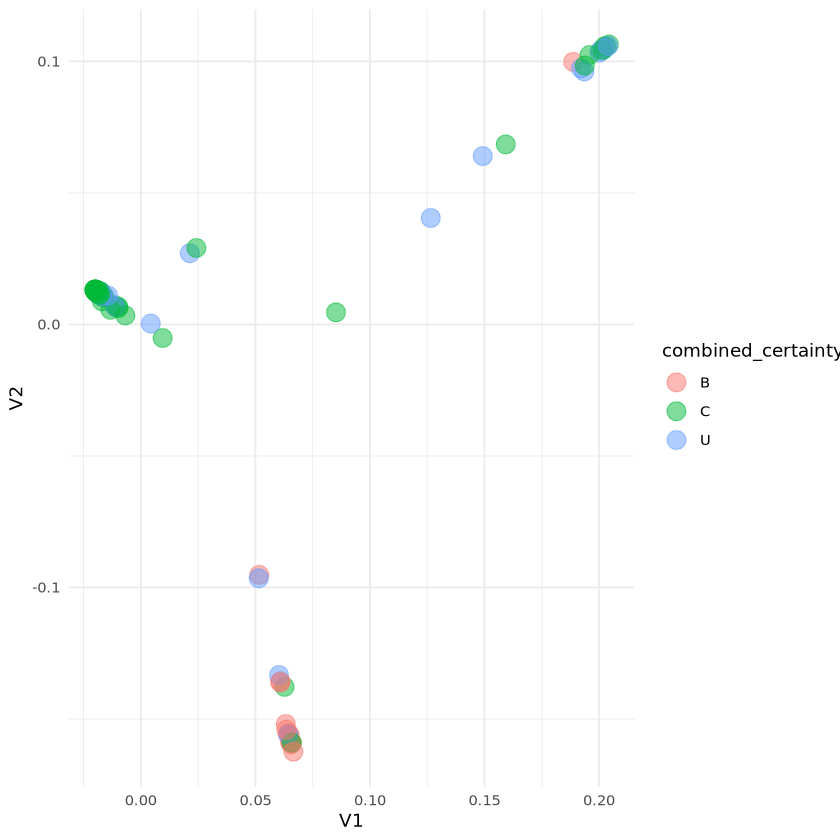

In [25]:
#Some patterns in field morphology vs genetics for sure. Unsurprising.
ggplot(combined24, aes(x=V1, y=V2,color=combined_certainty)) + geom_point(shape=19,size=5,alpha=0.5) +theme_minimal()

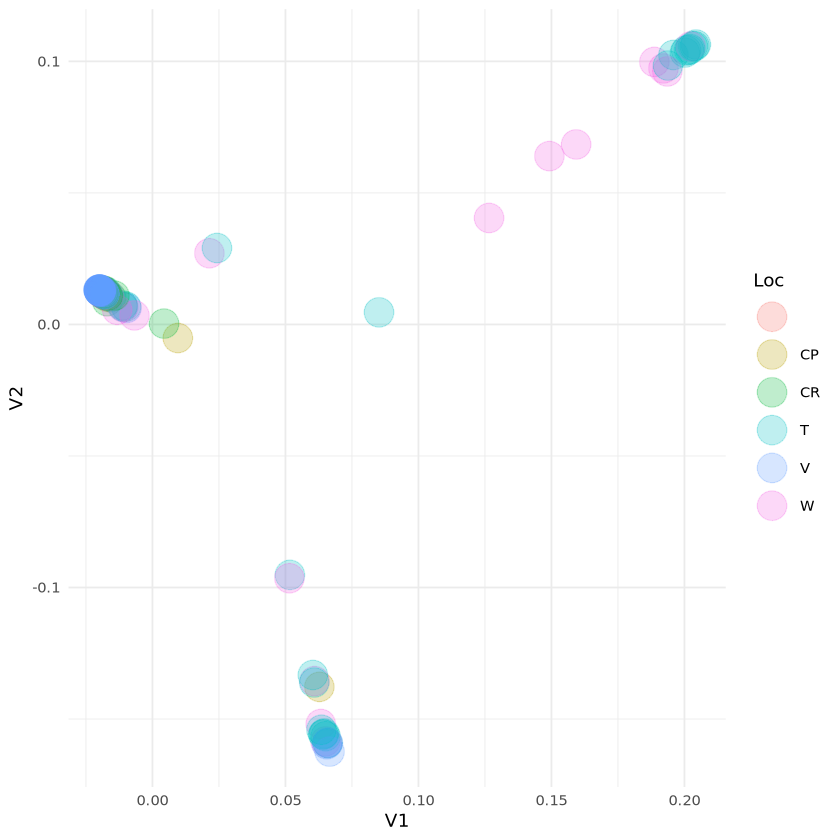

In [26]:
#Patterns with sampling area as well
ggplot(combined24, aes(x=V1, y=V2,color=Loc)) + geom_point(shape=19,size=8,alpha=0.25) +theme_minimal()

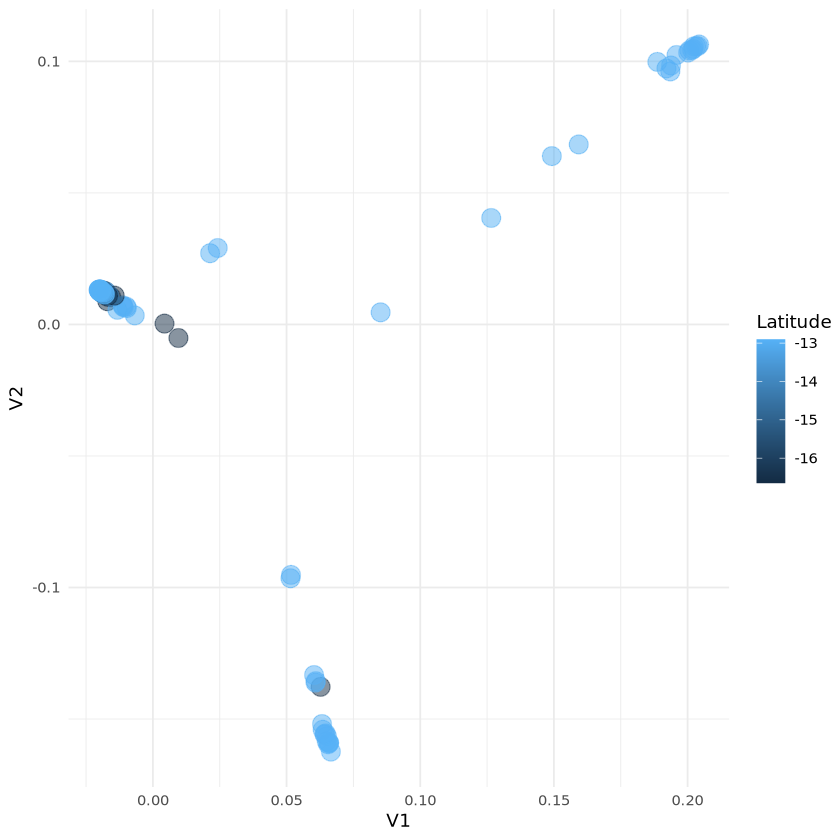

In [27]:
#And broad scale site
ggplot(combined24, aes(x=V1, y=V2,color=Latitude)) + geom_point(shape=19,size=5,alpha=0.5) +theme_minimal()

In [29]:
#Include ADMIXTURE data
k8_admix <- as.data.frame(read.table("/scratch/jbos/Moz_aligned_mil/angsd1_output/k8_admix.txt",header=TRUE))
k8_admix$IND<-k8_admix$ind_names

In [30]:
#Merge with PCA and metadata
combined_pca<-left_join(combined_pca,k8_admix)

Joining with `by = join_by(IND)`


In [31]:
#Look at ancestry groupings. Table of individuals by predominant ancestry fraction
table(combined_pca$main_frac)


Grp1 Grp2 Grp3 Grp4 Grp5 Grp6 Grp7 Grp8 
  73   14   86    8   16   27   77    9 

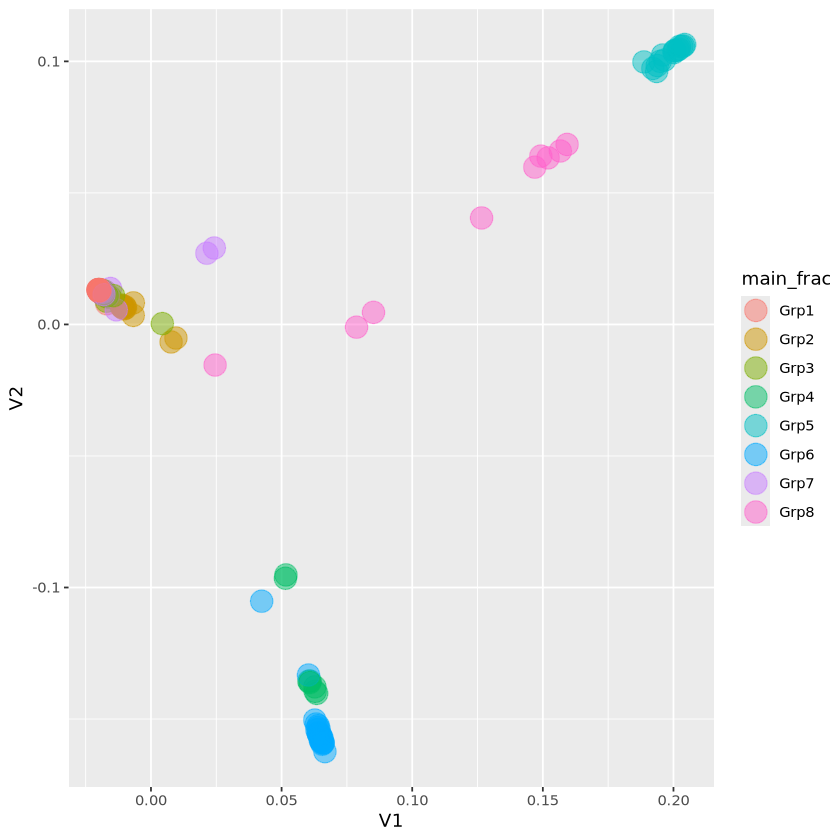

In [32]:
#Color PCA by predominant ancestry fraction
ggplot(combined_pca, aes(x=V1, y=V2,color=main_frac)) + geom_point(shape=19,size=6,alpha=0.5) + scale_fill_viridis(discrete=TRUE)

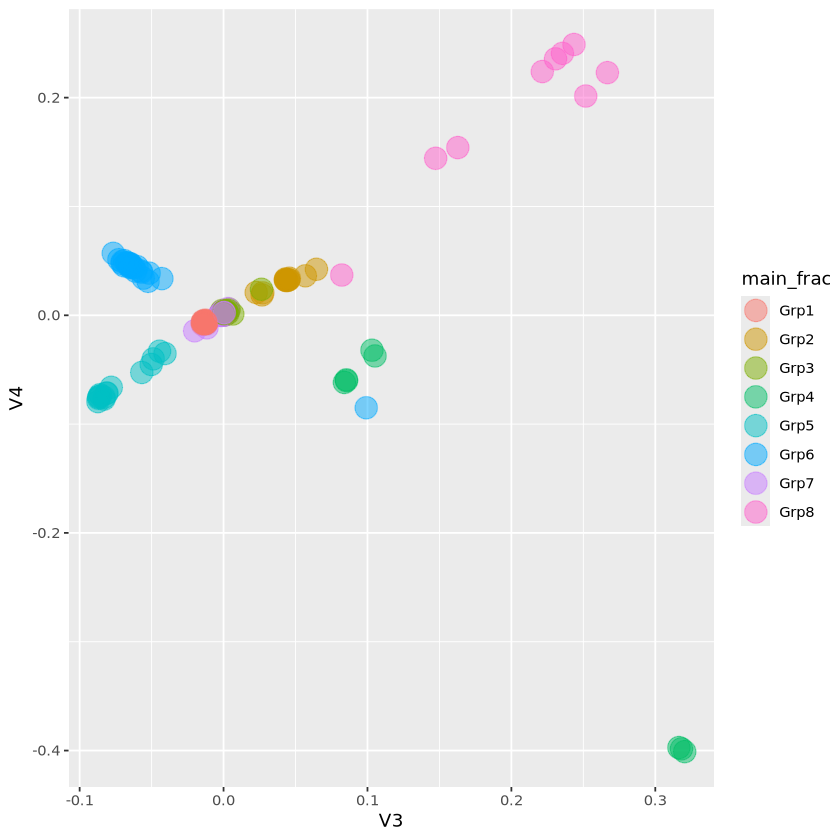

In [33]:
#Check higher order PCs
ggplot(combined_pca, aes(x=V3, y=V4,color=main_frac)) + geom_point(shape=19,size=6,alpha=0.5) + scale_fill_viridis(discrete=TRUE)

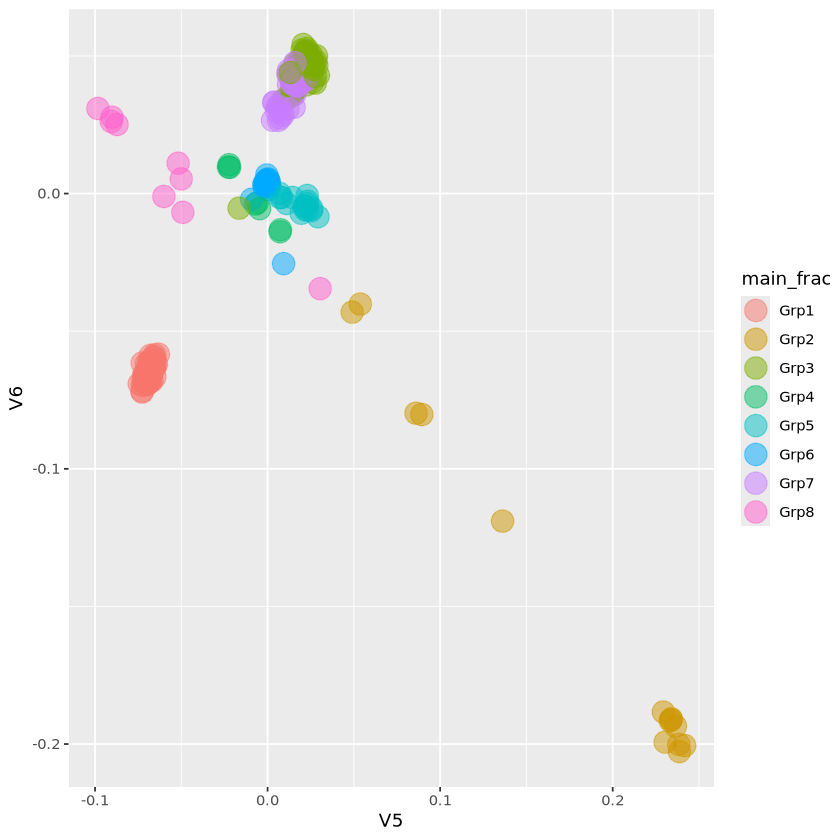

In [34]:
#Check higher order PCs
ggplot(combined_pca, aes(x=V5, y=V6,color=main_frac)) + geom_point(shape=19,size=6,alpha=0.5) + scale_fill_viridis(discrete=TRUE)

In [35]:
#Seems like the morphologically distinct "spp B" belong to groups 4 and 6 (closely associated on PCA)
table(combined_pca[combined_pca$AltSpp=='B',]$main_frac)


Grp4 Grp5 Grp6 
   3    1   10 

In [36]:
#Nearly everything on Caldeira belongs to group 3
table(combined_pca[combined_pca$Loc=='CP',]$main_frac)
table(combined_pca[combined_pca$Loc=='CR',]$main_frac)


Grp2 Grp3 Grp4 
   1   29    1 


Grp3 
  37 

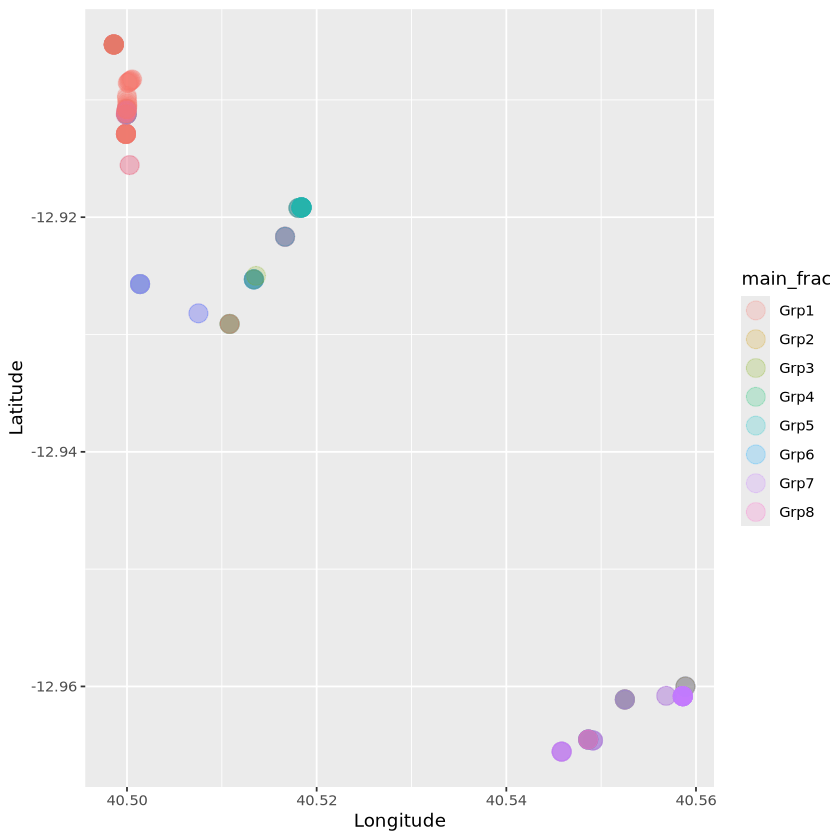

In [41]:
#This is basically just a map of Pemba, colored by predominant ancestry fraction. Strong patterns here
ggplot(combined_pca[combined_pca$Longitude>40,], aes(x=Longitude, y=Latitude,color=main_frac)) + geom_point(shape=19,size=5,alpha=0.2)

In [43]:
#Check sampled locations for each ancestry group
Grp1<-combined_pca[combined_pca$main_frac=='Grp1',]
table(Grp1$Loc)


   CP CR  T  V  W 
 0  0  0  0 73  0 

In [44]:
#Check sampled locations for each ancestry group
Grp2<-combined_pca[combined_pca$main_frac=='Grp2',]
table(Grp2$Loc)


   CP CR  T  V  W 
 0  1  0  3  3  2 

In [45]:
#Check sampled locations for each ancestry group
Grp3<-combined_pca[combined_pca$main_frac=='Grp3',]
table(Grp3$Loc)


   CP CR  T  V  W 
 2 29 37  5  3 10 

In [46]:
#Check sampled locations for each ancestry group
Grp4<-combined_pca[combined_pca$main_frac=='Grp4',]
table(Grp4$Loc)


   CP CR  T  V  W 
 0  1  0  4  0  2 

In [47]:
#Check sampled locations for each ancestry group
Grp5<-combined_pca[combined_pca$main_frac=='Grp5',]
table(Grp5$Loc)


   CP CR  T  V  W 
 0  0  0  9  0  4 

In [48]:
#Check sampled locations for each ancestry group
Grp6<-combined_pca[combined_pca$main_frac=='Grp6',]
table(Grp6$Loc)


   CP CR  T  V  W 
 0  0  0  8  6  5 

In [50]:
#Check sampled locations for each ancestry group
Grp7<-combined_pca[combined_pca$main_frac=='Grp7',]
table(Grp7$Loc)


   CP CR  T  V  W 
 0  0  0  7 17 51 

In [51]:
#Check sampled locations for each ancestry group
Grp8<-combined_pca[combined_pca$main_frac=='Grp8',]
table(Grp8$Loc)


   CP CR  T  V  W 
 0  0  0  1  0  5 

In [52]:
#Function makes list of BAMfiles for each group
bamlist<-function(ind){
    a<-paste0('/scratch/jbos/Moz_aligned_mil/amillepora_bamfiles/',ind)
    b<-paste0(a,'.sorted.bam')
    return(b)
    }

In [38]:
bamlist_clad<-function(ind){
    a<-paste0('/scratch/jbos/Moz_Cladocopium/cladocopium_bamfiles/',ind)
    b<-paste0(a,'.sorted.bam')
    return(b)
    }

In [39]:
bamlist_dur<-function(ind){
    a<-paste0('/scratch/jbos/Moz_Durusdinium/durusdinium_bamfiles/',ind)
    b<-paste0(a,'.sorted.bam')
    return(b)
    }

In [40]:
bamlist_sym<-function(ind){
    a<-paste0('/scratch/jbos/Moz_Symbiodinium/symbiodinium_bamfiles/',ind)
    b<-paste0(a,'.sorted.bam')
    return(b)
    }

In [32]:
a<-Grp1$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp1.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [33]:
a<-Grp2$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp2.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [34]:
a<-Grp3$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp3.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [35]:
a<-Grp4$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp4.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [36]:
a<-Grp5$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp5.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [37]:
a<-Grp6$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp6.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [38]:
a<-Grp7$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp7.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [39]:
a<-Grp8$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp8.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [42]:
Grp37<-bind_rows(Grp3,Grp7)
table(Grp37$Loc)
nrow(Grp37)


   CP CR  T  V  W 
 2 29 37 12 20 61 

[1] 163

In [43]:
a<-Grp37$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp37.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [40]:
Grp137<-bind_rows(Grp1,Grp3,Grp7)
table(Grp137$Loc)
nrow(Grp137)


   CP CR  T  V  W 
 2 29 37 12 93 61 

[1] 236

In [41]:
a<-Grp137$ind_names
a<-bamlist(a)
write.table(a,'/home/jbos/Moz_reads/bam_names_grp137.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [55]:
symbiont_counts<-read.csv('/home/jbos/Moz_reads/symbiodiniaceae_all.csv',header=TRUE)
symbiont_counts

IND,clad_reads,dur_reads,sym_reads,max_frac
<chr>,<int>,<int>,<int>,<chr>
ACR_003,10534274,5568285,8490586,clad_reads
ACR_006,5694478,3311514,4982271,clad_reads
ACR_010,6490639,3207320,4622655,clad_reads
ACR_011,6648548,2852944,3963477,clad_reads
ACR_018,8662414,4668763,7704237,clad_reads
ACR_019,2600506,1458220,2178367,clad_reads
ACR_027,3580569,2043192,3054386,clad_reads
ACR_030,4794718,2755408,4065432,clad_reads
ACR_032,871619,509206,764204,clad_reads


In [57]:
clad_inds<-symbiont_counts[symbiont_counts$clad_reads>0,]$IND
dur_inds<-symbiont_counts[symbiont_counts$dur_reads>0,]$IND
sym_inds<-symbiont_counts[symbiont_counts$sym_reads>0,]$IND

In [65]:
a<-Grp137$ind_names
a<-a[a %in% clad_inds]
a<-bamlist_clad(a)
write.table(a,'/home/jbos/Moz_reads/bam_cladocopium_grp137.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [66]:
a<-Grp137$ind_names
a<-a[a %in% dur_inds]
a<-bamlist_dur(a)
write.table(a,'/home/jbos/Moz_reads/bam_durusdinium_grp137.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [67]:
a<-Grp137$ind_names
a<-a[a %in% sym_inds]
a<-bamlist_sym(a)
write.table(a,'/home/jbos/Moz_reads/bam_symbiodinium_grp137.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)